# 🔧 Notebook 02 — Preprocesamiento de Datos
## NHANES 2015-2016 · Ciclo I · Autor: Álvaro

**Objetivo:** Limpiar, imputar y transformar la tabla maestra para dejarla lista para modelado.  
Se produce un dataset procesado que se guarda en `data/02_intermediate/`.

**Pasos:**
1. Carga y corrección de valores SAS missing
2. Selección de variables útiles (de 227 → subconjunto relevante)
3. Limpieza: filtrado de adultos y eliminación de registros sin edad
4. Imputación de valores faltantes (KNN Imputer / SimpleImputer)
5. Codificación de variables categóricas (One-Hot Encoding)
6. Escalado de variables numéricas (StandardScaler)
7. Creación de la variable objetivo `IS_LONGEVO`
8. Exportación del resultado a `data/02_intermediate/`

---

## 1. Importación de librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import json

from sklearn.impute import KNNImputer, SimpleImputer
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.15)

print('✅ Librerías cargadas correctamente.')

✅ Librerías cargadas correctamente.


## 2. Carga de datos crudos

In [2]:
DATA_PATH = '../data/01_raw/nhanes_2015_maestra.csv'
df_raw = pd.read_csv(DATA_PATH)
print(f'📦 Datos crudos cargados: {df_raw.shape[0]:,} filas × {df_raw.shape[1]} columnas')
df_raw.head(3)

📦 Datos crudos cargados: 14,022 filas × 288 columnas


,SEQN,SDDSRVYR,RIDSTATR,RIAGENDR,RIDAGEYR,RIDAGEMN,RIDRETH1,RIDRETH3,RIDEXMON,RIDEXAGM,...,MCQ265,MCQ268A,MCQ268B,MCQ268C,MCQ268D,MCQ310,MCQ320,MCD330,MCQ340,MCQ350
0,83732.0,9.0,2.0,1.0,62.0,NaN,3.0,3.0,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,83733.0,9.0,2.0,1.0,53.0,NaN,3.0,3.0,1.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,83734.0,9.0,2.0,1.0,78.0,NaN,3.0,3.0,2.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## 3. ⚠️ Corrección de valores SAS missing

Los archivos `.XPT` de NHANES codifican ciertos valores faltantes como números extremadamente pequeños (`~5.4e-79`) en lugar de `NaN`.  
Esto afecta a 25 columnas y ~23,895 celdas. Es **crítico** corregirlo antes de cualquier cálculo.

In [3]:
SAS_MISSING_THRESHOLD = 1e-70

# Contar y reemplazar valores SAS missing
n_sas_total = 0
cols_afectadas = []
for col in df_raw.select_dtypes(include=[np.number]).columns:
    mask = (df_raw[col] > 0) & (df_raw[col] < SAS_MISSING_THRESHOLD)
    n = mask.sum()
    if n > 0:
        n_sas_total += n
        cols_afectadas.append((col, n))
        df_raw.loc[mask, col] = np.nan

print(f'🔍 Valores SAS missing reemplazados por NaN: {n_sas_total:,}')
print(f'   Columnas afectadas: {len(cols_afectadas)}')
for col, n in sorted(cols_afectadas, key=lambda x: -x[1])[:10]:
    print(f'      {col}: {n:,}')
print(f'   ...')

🔍 Valores SAS missing reemplazados por NaN: 0
   Columnas afectadas: 0
   ...


## 4. Selección de variables relevantes

De las 227 columnas disponibles, seleccionamos las más relevantes para predecir **Edad Biológica** y **Longevidad**:  
- **Demográficas:** edad, género, etnia, educación, estado civil, ingresos  
- **Antropométricas:** peso, talla, IMC, cintura  
- **Presión arterial:** sistólica, diastólica, pulso  
- **Laboratorio:** colesterol total, glucosa  

Se excluyen variables de cuestionario (MCQ, SMQ) por su alto % de nulos y naturaleza subjetiva.

In [4]:
# ── Definir columnas a conservar ───────────────────────────────────────

# Identificador
cols_id = ['SEQN']

# Demográficas
cols_demo = [
    'RIDAGEYR',   # Edad en años (target para regresión)
    'RIAGENDR',   # Género (1=M, 2=F) — categórica
    'RIDRETH3',   # Raza/Etnia — categórica
    'DMDEDUC2',   # Nivel educativo (adultos ≥20) — categórica ordinal
    'DMDMARTL',   # Estado civil — categórica
    'DMDHHSIZ',   # Tamaño del hogar
    'DMDFMSIZ',   # Tamaño de la familia
    'INDFMPIR',   # Ratio ingreso/pobreza
]

# Antropométricas (BMX)
cols_bmx = [
    'BMXWT',      # Peso (kg)
    'BMXHT',      # Talla (cm)
    'BMXBMI',     # Índice de Masa Corporal
    'BMXWAIST',   # Circunferencia de cintura (cm)
    'BMXLEG',     # Longitud de pierna (cm)
    'BMXARML',    # Longitud de brazo (cm)
    'BMXARMC',    # Circunferencia de brazo (cm)
]

# Presión arterial (BPX) — 3 lecturas + pulso
cols_bp = [
    'BPXSY1', 'BPXDI1',   # 1ᵃ lectura sistólica y diastólica
    'BPXSY2', 'BPXDI2',   # 2ᵃ lectura
    'BPXSY3', 'BPXDI3',   # 3ᵃ lectura
    'BPXPLS',             # Pulso (latidos/min)
]

# Laboratorio (LBX)
cols_lab = [
    'LBXTC',      # Colesterol total (mg/dL)
    'LBXGLU',     # Glucosa en ayunas (mg/dL)
]

# Construir lista final (solo columnas que existan en el dataset)
cols_deseadas = cols_id + cols_demo + cols_bmx + cols_bp + cols_lab
cols_seleccion = [c for c in cols_deseadas if c in df_raw.columns]
cols_faltantes = [c for c in cols_deseadas if c not in df_raw.columns]

if cols_faltantes:
    print(f'⚠️ Columnas solicitadas pero no encontradas: {cols_faltantes}')

df = df_raw[cols_seleccion].copy()
print(f'\n✂️ Variables seleccionadas: {df.shape[1]} de {df_raw.shape[1]}')
print(f'   Demográficas:     {len([c for c in cols_demo if c in df.columns])}')
print(f'   Antropométricas:  {len([c for c in cols_bmx if c in df.columns])}')
print(f'   Presión arterial: {len([c for c in cols_bp if c in df.columns])}')
print(f'   Laboratorio:      {len([c for c in cols_lab if c in df.columns])}')
df.head()


✂️ Variables seleccionadas: 25 de 288
   Demográficas:     8
   Antropométricas:  7
   Presión arterial: 7
   Laboratorio:      2


,SEQN,RIDAGEYR,RIAGENDR,RIDRETH3,DMDEDUC2,DMDMARTL,DMDHHSIZ,DMDFMSIZ,INDFMPIR,BMXWT,...,BMXARMC,BPXSY1,BPXDI1,BPXSY2,BPXDI2,BPXSY3,BPXDI3,BPXPLS,LBXTC,LBXGLU
0,83732.0,62.0,1.0,3.0,5.0,1.0,2.0,2.0,4.39,94.8,...,35.9,128.0,70.0,124.0,64.0,116.0,62.0,76.0,173.0,NaN
1,83733.0,53.0,1.0,3.0,3.0,3.0,1.0,1.0,1.32,90.4,...,33.2,146.0,88.0,140.0,88.0,134.0,82.0,72.0,265.0,101.0
2,83734.0,78.0,1.0,3.0,3.0,1.0,2.0,2.0,1.51,83.4,...,31.0,138.0,46.0,132.0,44.0,136.0,46.0,56.0,229.0,84.0
3,83735.0,56.0,2.0,3.0,5.0,6.0,1.0,1.0,5.00,109.8,...,38.3,132.0,72.0,134.0,68.0,136.0,70.0,78.0,174.0,NaN
4,83736.0,42.0,2.0,4.0,4.0,3.0,5.0,5.0,1.23,55.2,...,27.2,100.0,70.0,114.0,54.0,98.0,56.0,76.0,204.0,84.0


## 5. Limpieza: filtrado de registros

Se eliminan registros donde la **edad** es nula y se filtran solo **adultos (≥18 años)** para asegurar coherencia en variables como `DMDEDUC2` y `DMDMARTL`.

In [5]:
# Eliminar filas sin edad
antes = len(df)
df = df.dropna(subset=['RIDAGEYR'])
print(f'🧹 Eliminados {antes - len(df)} registros sin edad.')

# Filtrar solo adultos (≥ 18 años)
antes = len(df)
df = df[df['RIDAGEYR'] >= 18].copy()
print(f'🧹 Filtrado a adultos (≥18): {antes - len(df)} menores eliminados.')
print(f'📊 Dataset actual: {df.shape[0]:,} filas × {df.shape[1]} columnas')

🧹 Eliminados 396 registros sin edad.
🧹 Filtrado a adultos (≥18): 3583 menores eliminados.
📊 Dataset actual: 10,043 filas × 25 columnas


In [6]:
# ── Revisar nulos después de la limpieza ───────────────────────────────
nulos = df.isnull().sum()
pct_nulos = (nulos / len(df) * 100).round(2)

df_nulos = pd.DataFrame({
    'Nulos': nulos,
    '% Nulos': pct_nulos
}).sort_values('% Nulos', ascending=False)

print('🔍 Estado de nulos tras limpieza:')
df_nulos[df_nulos['Nulos'] > 0]

🔍 Estado de nulos tras limpieza:


,Nulos,% Nulos
LBXGLU,5664,56.40
RIDRETH3,2267,22.57
BMXLEG,1333,13.27
BMXWAIST,1320,13.14
BPXDI1,1217,12.12
BPXDI3,1177,11.72
INDFMPIR,1176,11.71
BMXARMC,1176,11.71
BMXARML,1173,11.68
BPXSY1,1135,11.30


## 6. Creación de la variable objetivo `IS_LONGEVO`

In [7]:
# Variable binaria: 1 si el paciente tiene ≥ 70 años, 0 en caso contrario
df['IS_LONGEVO'] = (df['RIDAGEYR'] >= 70).astype(int)

conteo = df['IS_LONGEVO'].value_counts()
print('📊 Distribución de IS_LONGEVO (solo adultos):')
print(f'   No Longevo (0): {conteo.get(0, 0):,}  ({conteo.get(0, 0)/len(df)*100:.1f}%)')
print(f'   Longevo    (1): {conteo.get(1, 0):,}  ({conteo.get(1, 0)/len(df)*100:.1f}%)')

📊 Distribución de IS_LONGEVO (solo adultos):
   No Longevo (0): 5,040  (50.2%)
   Longevo    (1): 5,003  (49.8%)


## 7. Separación en variables numéricas y categóricas

In [8]:
# ── Definir tipos de variables ─────────────────────────────────────────
col_id = 'SEQN'
col_target_bin = 'IS_LONGEVO'
col_target_cont = 'RIDAGEYR'

# Variables categóricas (codificadas como numéricas en NHANES)
cols_categoricas = ['RIAGENDR', 'RIDRETH3', 'DMDEDUC2', 'DMDMARTL']
cols_categoricas = [c for c in cols_categoricas if c in df.columns]

# Variables numéricas (features reales)
cols_numericas = [
    'DMDHHSIZ', 'DMDFMSIZ', 'INDFMPIR',
    'BMXWT', 'BMXHT', 'BMXBMI', 'BMXWAIST', 'BMXLEG', 'BMXARML', 'BMXARMC',
    'BPXSY1', 'BPXDI1', 'BPXSY2', 'BPXDI2', 'BPXSY3', 'BPXDI3', 'BPXPLS',
    'LBXTC', 'LBXGLU',
]
cols_numericas = [c for c in cols_numericas if c in df.columns]

print(f'📋 Variables categóricas ({len(cols_categoricas)}): {cols_categoricas}')
print(f'📋 Variables numéricas   ({len(cols_numericas)}): {cols_numericas}')
print(f'🎯 Target binario:  {col_target_bin}')
print(f'🎯 Target continuo: {col_target_cont}')

📋 Variables categóricas (4): ['RIAGENDR', 'RIDRETH3', 'DMDEDUC2', 'DMDMARTL']
📋 Variables numéricas   (19): ['DMDHHSIZ', 'DMDFMSIZ', 'INDFMPIR', 'BMXWT', 'BMXHT', 'BMXBMI', 'BMXWAIST', 'BMXLEG', 'BMXARML', 'BMXARMC', 'BPXSY1', 'BPXDI1', 'BPXSY2', 'BPXDI2', 'BPXSY3', 'BPXDI3', 'BPXPLS', 'LBXTC', 'LBXGLU']
🎯 Target binario:  IS_LONGEVO
🎯 Target continuo: RIDAGEYR


## 8. Imputación de valores nulos

**Estrategia:**
- **Variables numéricas:** `KNNImputer` con k=5 vecinos. Preserva la estructura local de los datos.
- **Variables categóricas:** `SimpleImputer` con estrategia `most_frequent` (moda).

In [9]:
# ── Imputación de variables numéricas (KNN Imputer) ────────────────────
print('⏳ Imputando variables numéricas con KNNImputer (k=5)...')
print(f'   Nulos antes: {df[cols_numericas].isnull().sum().sum():,}')

knn_imputer = KNNImputer(n_neighbors=5, weights='uniform')
df[cols_numericas] = knn_imputer.fit_transform(df[cols_numericas])

print(f'   ✅ Nulos después: {df[cols_numericas].isnull().sum().sum()}')

⏳ Imputando variables numéricas con KNNImputer (k=5)...
   Nulos antes: 22,442
   ✅ Nulos después: 0


In [10]:
# ── Imputación de variables categóricas (Moda) ─────────────────────────
print('⏳ Imputando variables categóricas con SimpleImputer (moda)...')
print(f'   Nulos antes: {df[cols_categoricas].isnull().sum().sum():,}')

simple_imputer = SimpleImputer(strategy='most_frequent')
df[cols_categoricas] = simple_imputer.fit_transform(df[cols_categoricas])

print(f'   ✅ Nulos después: {df[cols_categoricas].isnull().sum().sum()}')

⏳ Imputando variables categóricas con SimpleImputer (moda)...
   Nulos antes: 2,813
   ✅ Nulos después: 0


In [11]:
# ── Verificación final de nulos ────────────────────────────────────────
total_nulos = df.isnull().sum().sum()
print(f'\n🎉 Total de valores nulos en el dataset: {total_nulos}')
assert total_nulos == 0, '¡ERROR! Aún quedan nulos en el dataset.'
print('✅ ¡Dataset libre de nulos!')


🎉 Total de valores nulos en el dataset: 0
✅ ¡Dataset libre de nulos!


## 9. Codificación de variables categóricas

Se utiliza **One-Hot Encoding** para las variables categóricas nominales.  
Se aplica `drop_first=True` para evitar multicolinealidad perfecta.

In [12]:
print('⏳ Codificando variables categóricas (One-Hot Encoding)...')

# Convertir a string para que pd.get_dummies las trate correctamente
for col in cols_categoricas:
    df[col] = df[col].astype(int).astype(str)

df_encoded = pd.get_dummies(df, columns=cols_categoricas, drop_first=True, dtype=int)

print(f'   Columnas antes:  {df.shape[1]}')
print(f'   Columnas después: {df_encoded.shape[1]}')

# Identificar las columnas dummy creadas
cols_dummy = [c for c in df_encoded.columns if any(c.startswith(cat + '_') for cat in cols_categoricas)]
print(f'   Nuevas columnas dummy ({len(cols_dummy)}):')
for col in cols_dummy:
    print(f'      • {col}')

df_encoded.head()

⏳ Codificando variables categóricas (One-Hot Encoding)...
   Columnas antes:  26
   Columnas después: 41
   Nuevas columnas dummy (19):
      • RIAGENDR_2
      • RIDRETH3_2
      • RIDRETH3_3
      • RIDRETH3_4
      • RIDRETH3_6
      • RIDRETH3_7
      • DMDEDUC2_2
      • DMDEDUC2_3
      • DMDEDUC2_4
      • DMDEDUC2_5
      • DMDEDUC2_7
      • DMDEDUC2_9
      • DMDMARTL_2
      • DMDMARTL_3
      • DMDMARTL_4
      • DMDMARTL_5
      • DMDMARTL_6
      • DMDMARTL_77
      • DMDMARTL_99


,SEQN,RIDAGEYR,DMDHHSIZ,DMDFMSIZ,INDFMPIR,BMXWT,BMXHT,BMXBMI,BMXWAIST,BMXLEG,...,DMDEDUC2_5,DMDEDUC2_7,DMDEDUC2_9,DMDMARTL_2,DMDMARTL_3,DMDMARTL_4,DMDMARTL_5,DMDMARTL_6,DMDMARTL_77,DMDMARTL_99
0,83732.0,62.0,2.0,2.0,4.39,94.8,184.5,27.8,101.1,43.3,...,1,0,0,0,0,0,0,0,0,0
1,83733.0,53.0,1.0,1.0,1.32,90.4,171.4,30.8,107.9,38.0,...,0,0,0,0,1,0,0,0,0,0
2,83734.0,78.0,2.0,2.0,1.51,83.4,170.1,28.8,116.5,35.6,...,0,0,0,0,0,0,0,0,0,0
3,83735.0,56.0,1.0,1.0,5.00,109.8,160.9,42.4,110.1,38.5,...,1,0,0,0,0,0,0,1,0,0
4,83736.0,42.0,5.0,5.0,1.23,55.2,164.9,20.3,80.4,37.4,...,0,0,0,0,1,0,0,0,0,0


## 10. Escalado de variables numéricas (StandardScaler)

El escalado normaliza las variables numéricas a media=0 y desviación estándar=1.  
Es **crítico** para PCA, KNN, Regresión Logística y SVM.  

> **NOTA:** No escalamos `RIDAGEYR` (target de regresión), `IS_LONGEVO` (target binario), `SEQN` (ID), ni las variables dummy.

In [13]:
# ── Identificar columnas a escalar ─────────────────────────────────────
cols_a_escalar = [c for c in cols_numericas if c in df_encoded.columns]

print(f'📏 Variables a escalar ({len(cols_a_escalar)}): {cols_a_escalar}')

scaler = StandardScaler()
df_encoded[cols_a_escalar] = scaler.fit_transform(df_encoded[cols_a_escalar])

print('✅ Escalado aplicado con StandardScaler.')

# Verificar medias post-escalado
print('\n   Verificación de medias post-escalado:')
for col in cols_a_escalar:
    print(f'      {col}: μ={df_encoded[col].mean():.4f}, σ={df_encoded[col].std():.4f}')

📏 Variables a escalar (19): ['DMDHHSIZ', 'DMDFMSIZ', 'INDFMPIR', 'BMXWT', 'BMXHT', 'BMXBMI', 'BMXWAIST', 'BMXLEG', 'BMXARML', 'BMXARMC', 'BPXSY1', 'BPXDI1', 'BPXSY2', 'BPXDI2', 'BPXSY3', 'BPXDI3', 'BPXPLS', 'LBXTC', 'LBXGLU']
✅ Escalado aplicado con StandardScaler.

   Verificación de medias post-escalado:
      DMDHHSIZ: μ=0.0000, σ=1.0000
      DMDFMSIZ: μ=0.0000, σ=1.0000
      INDFMPIR: μ=-0.0000, σ=1.0000
      BMXWT: μ=-0.0000, σ=1.0000
      BMXHT: μ=0.0000, σ=1.0000
      BMXBMI: μ=0.0000, σ=1.0000
      BMXWAIST: μ=0.0000, σ=1.0000
      BMXLEG: μ=0.0000, σ=1.0000
      BMXARML: μ=-0.0000, σ=1.0000
      BMXARMC: μ=-0.0000, σ=1.0000
      BPXSY1: μ=0.0000, σ=1.0000
      BPXDI1: μ=0.0000, σ=1.0000
      BPXSY2: μ=0.0000, σ=1.0000
      BPXDI2: μ=0.0000, σ=1.0000
      BPXSY3: μ=0.0000, σ=1.0000
      BPXDI3: μ=0.0000, σ=1.0000
      BPXPLS: μ=0.0000, σ=1.0000
      LBXTC: μ=0.0000, σ=1.0000
      LBXGLU: μ=-0.0000, σ=1.0000


## 11. Visualización post-procesamiento

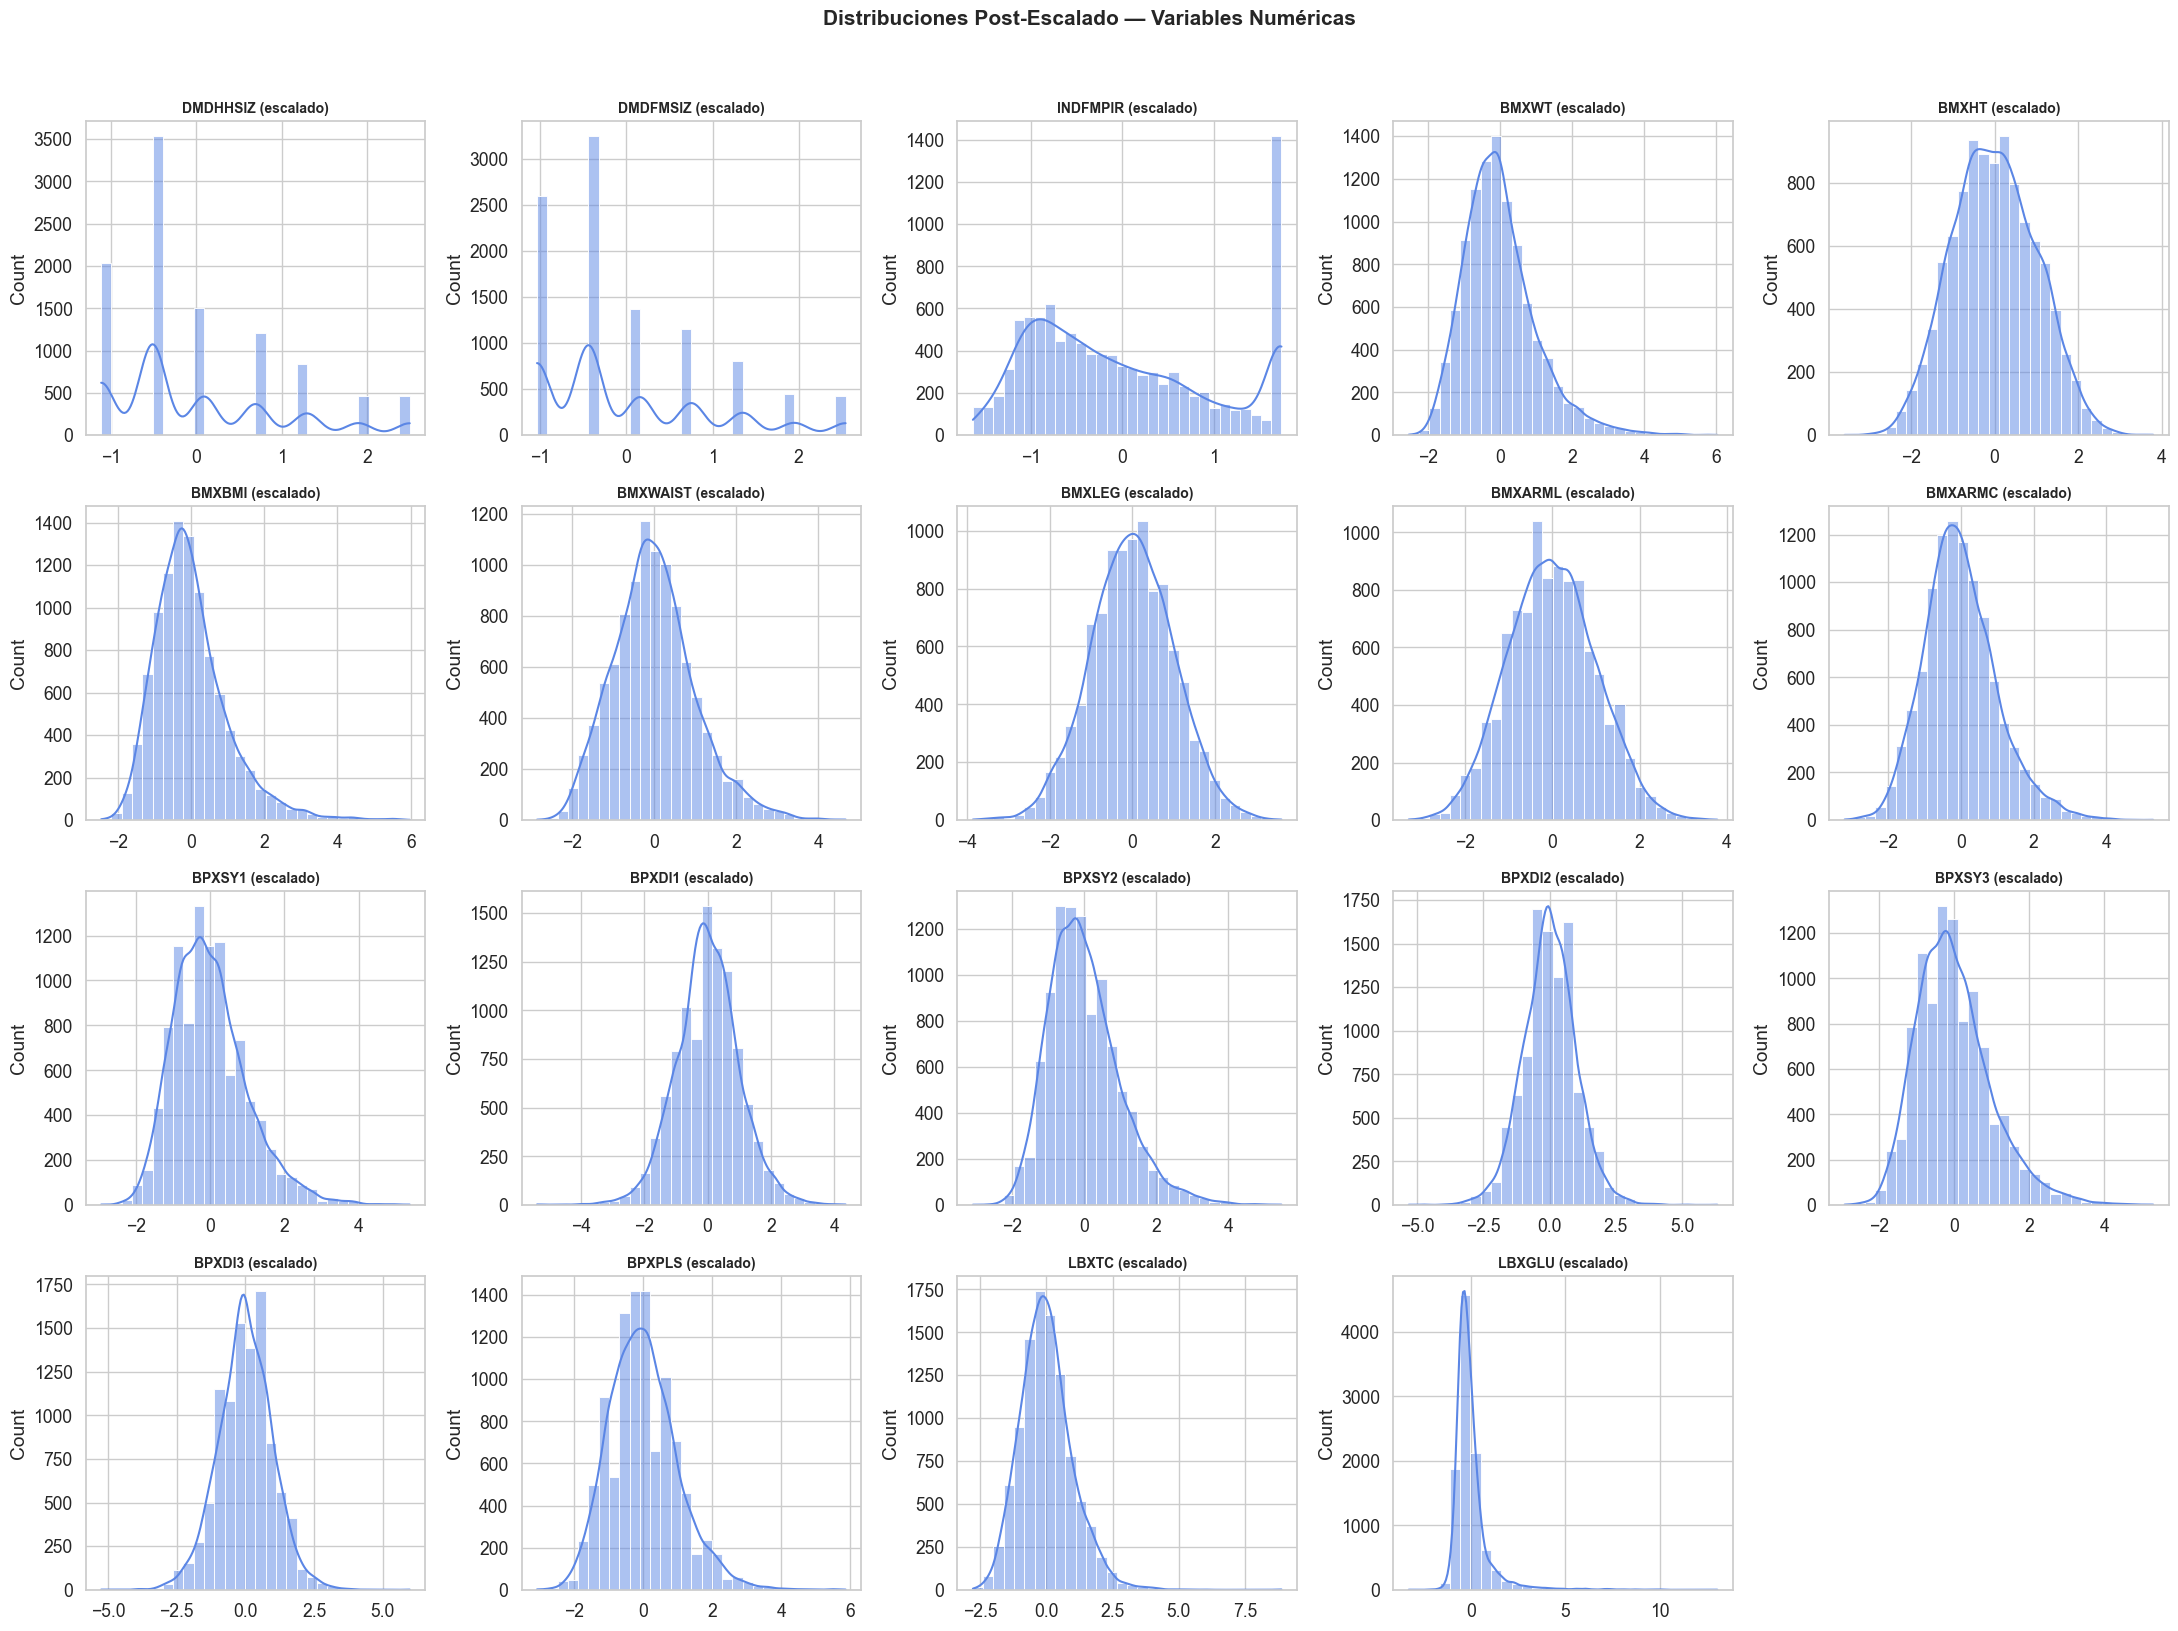

In [14]:
# ── Distribución de las variables escaladas ────────────────────────────
n_vars = len(cols_a_escalar)
n_cols_plot = 5
n_rows_plot = (n_vars + n_cols_plot - 1) // n_cols_plot

fig, axes = plt.subplots(n_rows_plot, n_cols_plot, figsize=(22, 4 * n_rows_plot))
axes = axes.flatten()

for i, col in enumerate(cols_a_escalar):
    sns.histplot(df_encoded[col], bins=30, kde=True, color='#5B86E5', ax=axes[i])
    axes[i].set_title(f'{col} (escalado)', fontsize=10, fontweight='bold')
    axes[i].set_xlabel('')

# Ocultar subplots vacíos
for j in range(n_vars, len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribuciones Post-Escalado — Variables Numéricas',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [15]:
# ── Resumen del dataset final ──────────────────────────────────────────
todas_las_features = [c for c in df_encoded.columns if c not in ['SEQN', 'RIDAGEYR', 'IS_LONGEVO']]

print('=' * 60)
print('📋 RESUMEN DEL DATASET PROCESADO')
print('=' * 60)
print(f'   Filas:              {df_encoded.shape[0]:,}')
print(f'   Columnas totales:   {df_encoded.shape[1]}')
print(f'   Features:           {len(todas_las_features)}')
print(f'     - Numéricas escaladas: {len(cols_a_escalar)}')
print(f'     - Variables dummy:     {len(cols_dummy)}')
print(f'   Nulos restantes:    {df_encoded.isnull().sum().sum()}')
print(f'   Target binario:     IS_LONGEVO (0/1)')
print(f'   Target continuo:    RIDAGEYR (sin escalar)')
print('=' * 60)

df_encoded.describe().T.round(3)

📋 RESUMEN DEL DATASET PROCESADO
   Filas:              10,043
   Columnas totales:   41
   Features:           38
     - Numéricas escaladas: 19
     - Variables dummy:     19
   Nulos restantes:    0
   Target binario:     IS_LONGEVO (0/1)
   Target continuo:    RIDAGEYR (sin escalar)


,count,mean,std,min,25%,50%,75%,max
SEQN,10043.0,77506.109,15832.374,41477.000,64972.000,85325.000,89474.500,93702.000
RIDAGEYR,10043.0,59.500,20.039,18.000,42.500,69.000,77.000,80.000
DMDHHSIZ,10043.0,0.000,1.000,-1.118,-0.515,-0.515,0.692,2.502
DMDFMSIZ,10043.0,0.000,1.000,-1.038,-1.038,-0.441,0.754,2.545
INDFMPIR,10043.0,-0.000,1.000,-1.637,-0.831,-0.221,0.710,1.743
BMXWT,10043.0,-0.000,1.000,-2.522,-0.680,-0.121,0.513,6.025
BMXHT,10043.0,0.000,1.000,-3.586,-0.705,-0.033,0.701,3.794
BMXBMI,10043.0,0.000,1.000,-2.447,-0.670,-0.148,0.481,5.972
BMXWAIST,10043.0,0.000,1.000,-2.865,-0.678,-0.057,0.576,4.671
BMXLEG,10043.0,0.000,1.000,-3.853,-0.691,-0.006,0.679,3.604


## 12. Exportación a `data/02_intermediate/`

In [16]:
OUTPUT_DIR = '../data/02_intermediate'
OUTPUT_PATH = os.path.join(OUTPUT_DIR, 'nhanes_2015_procesado.csv')

os.makedirs(OUTPUT_DIR, exist_ok=True)

# Guardar sin el índice
df_encoded.to_csv(OUTPUT_PATH, index=False)

# Verificar tamaño del archivo
size_mb = os.path.getsize(OUTPUT_PATH) / (1024 * 1024)
print(f'💾 Dataset guardado en: {OUTPUT_PATH}')
print(f'   Tamaño: {size_mb:.2f} MB')
print(f'   Filas:  {df_encoded.shape[0]:,}')
print(f'   Cols:   {df_encoded.shape[1]}')

💾 Dataset guardado en: ../data/02_intermediate/nhanes_2015_procesado.csv
   Tamaño: 4.09 MB
   Filas:  10,043
   Cols:   41


In [17]:
# ── Verificación de lectura ────────────────────────────────────────────
df_verify = pd.read_csv(OUTPUT_PATH)
assert df_verify.shape == df_encoded.shape, '¡ERROR! Las dimensiones no coinciden.'
assert df_verify.isnull().sum().sum() == 0, '¡ERROR! Se introdujeron nulos al guardar.'
print('✅ Verificación exitosa — el archivo se lee correctamente.')
df_verify.head(3)

✅ Verificación exitosa — el archivo se lee correctamente.


,SEQN,RIDAGEYR,DMDHHSIZ,DMDFMSIZ,INDFMPIR,BMXWT,BMXHT,BMXBMI,BMXWAIST,BMXLEG,...,DMDEDUC2_5,DMDEDUC2_7,DMDEDUC2_9,DMDMARTL_2,DMDMARTL_3,DMDMARTL_4,DMDMARTL_5,DMDMARTL_6,DMDMARTL_77,DMDMARTL_99
0,83732.0,62.0,-0.514928,-0.440763,1.329418,0.784963,1.954133,-0.172424,0.066934,1.443243,...,1,0,0,0,0,0,0,0,0,0
1,83733.0,53.0,-1.118221,-1.037901,-0.749542,0.563483,0.629827,0.294223,0.510994,0.046600,...,0,0,0,0,1,0,0,0,0,0
2,83734.0,78.0,-0.514928,-0.440763,-0.620877,0.211127,0.498408,-0.016875,1.072599,-0.585841,...,0,0,0,0,0,0,0,0,0,0


## 13. Exportación de metadatos para los siguientes notebooks

In [18]:
# Guardar las listas de columnas para que los notebooks 03-05
# no tengan que recalcular qué columnas son features, categóricas, etc.
metadata = {
    'archivo_origen': 'nhanes_2015_maestra.csv',
    'archivo_procesado': 'nhanes_2015_procesado.csv',
    'n_filas': int(df_encoded.shape[0]),
    'n_columnas': int(df_encoded.shape[1]),
    'col_id': col_id,
    'col_target_binario': col_target_bin,
    'col_target_continuo': col_target_cont,
    'cols_numericas_escaladas': cols_a_escalar,
    'cols_dummy': cols_dummy,
    'todas_las_features': todas_las_features,
    'scaler': 'StandardScaler',
    'imputer_numerico': 'KNNImputer(n_neighbors=5)',
    'imputer_categorico': 'SimpleImputer(strategy=most_frequent)',
    'umbral_longevidad': 70,
    'filtro_edad_minima': 18,
    'sas_missing_corregidos': n_sas_total,
}

meta_path = os.path.join(OUTPUT_DIR, 'metadata_preprocesamiento.json')
with open(meta_path, 'w', encoding='utf-8') as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)

print(f'📝 Metadatos guardados en: {meta_path}')
print(json.dumps(metadata, indent=2, ensure_ascii=False))

📝 Metadatos guardados en: ../data/02_intermediate/metadata_preprocesamiento.json
{
  "archivo_origen": "nhanes_2015_maestra.csv",
  "archivo_procesado": "nhanes_2015_procesado.csv",
  "n_filas": 10043,
  "n_columnas": 41,
  "col_id": "SEQN",
  "col_target_binario": "IS_LONGEVO",
  "col_target_continuo": "RIDAGEYR",
  "cols_numericas_escaladas": [
    "DMDHHSIZ",
    "DMDFMSIZ",
    "INDFMPIR",
    "BMXWT",
    "BMXHT",
    "BMXBMI",
    "BMXWAIST",
    "BMXLEG",
    "BMXARML",
    "BMXARMC",
    "BPXSY1",
    "BPXDI1",
    "BPXSY2",
    "BPXDI2",
    "BPXSY3",
    "BPXDI3",
    "BPXPLS",
    "LBXTC",
    "LBXGLU"
  ],
  "cols_dummy": [
    "RIAGENDR_2",
    "RIDRETH3_2",
    "RIDRETH3_3",
    "RIDRETH3_4",
    "RIDRETH3_6",
    "RIDRETH3_7",
    "DMDEDUC2_2",
    "DMDEDUC2_3",
    "DMDEDUC2_4",
    "DMDEDUC2_5",
    "DMDEDUC2_7",
    "DMDEDUC2_9",
    "DMDMARTL_2",
    "DMDMARTL_3",
    "DMDMARTL_4",
    "DMDMARTL_5",
    "DMDMARTL_6",
    "DMDMARTL_77",
    "DMDMARTL_99"
  ],
  "todas

## 14. Conclusiones del Preprocesamiento

**Acciones realizadas:**

1. ✅ **Corrección SAS missing:** ~23,895 valores codificados como `~5.4e-79` convertidos a `NaN` real.
2. ✅ **Selección de variables:** De 227 → ~26 columnas relevantes (demográficas + antropometría + presión + laboratorio).
3. ✅ **Filtrado:** Solo adultos (≥18 años), sin registros sin edad.
4. ✅ **Imputación:** KNNImputer (k=5) para numéricas, SimpleImputer (moda) para categóricas → 0 nulos.
5. ✅ **Codificación:** One-Hot Encoding para 4 variables categóricas (`drop_first=True`).
6. ✅ **Escalado:** StandardScaler aplicado a ~19 variables numéricas (no escala targets ni dummies).
7. ✅ **Variable objetivo:** `IS_LONGEVO` = 1 si `RIDAGEYR ≥ 70`, 0 en caso contrario.
8. ✅ **Exportación:** `nhanes_2015_procesado.csv` + `metadata_preprocesamiento.json` en `data/02_intermediate/`.

**Siguiente paso:** Notebook 03 — Aprendizaje No Supervisado (PCA + K-Means).

---
*Notebook generado como parte del pipeline de Ciencia de Datos EV3 — NHANES 2015-2016*